# Experiment Analysis

Drop an experiment folder (from Colab or local training) into the path below and run all cells.

**Outputs:** learning curves, success rate, path-type breakdown, mood, Q-value policy maps, and summary stats.

In [1]:
# ---- CONFIG (edit these) ----
EXPERIMENT_DIR = "experiments/results_20260703_184227"  # path to experiment folder
MAZE_NAME = "shield_trap"  # maze used in the experiment
IMAGE_SIZE = 7  # image_size used during training (7 or 64)
ROLLING_WINDOW = 50  # smoothing window for plots

In [2]:
import sys, os
from pathlib import Path

# Make sure we can import project modules
PROJECT_ROOT = Path(os.path.abspath("")).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from collections import Counter

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

## 1. Load experiment data

In [3]:
from utils.visualization import load_experiment_results

exp_dir = Path(EXPERIMENT_DIR)
assert exp_dir.exists(), f"Experiment directory not found: {exp_dir}"

data = load_experiment_results(str(exp_dir))

for agent_type, df in data.items():
    n = len(df)
    print(f"{agent_type}: {n} episode rows")
    if n > 0:
        print(f"  columns: {list(df.columns)}")

# Load comparison JSON if available
comparison_files = list(exp_dir.glob("*_comparison.json"))
if comparison_files:
    with open(comparison_files[0]) as f:
        comparison_json = json.load(f)
    print(f"\nComparison summary loaded: {comparison_files[0].name}")
    for agent, stats in comparison_json.get("comparison", {}).items():
        print(f"  {agent}: success={stats.get('final_success_rate_mean', '?'):.1%}, "
              f"steps={stats.get('final_avg_steps_mean', '?'):.1f}")

baseline: 750 episode rows
  columns: ['episode', 'steps', 'total_reward', 'success', 'key_found_step', 'door_attempts_without_key', 'door_opened_step', 'shield_pickup_step', 'trap_hit_step', 'path_type', 'wall_bumps', 'mean_loss', 'mean_td_error', 'mean_q_value', 'mean_mood_value', 'mean_mood_action', 'mean_overall_mood', 'exploration_boosts', 'mean_mood_bias', 'epsilon', 'effective_epsilon', 'success_rate_100', 'run_id']
emotional: 750 episode rows
  columns: ['episode', 'steps', 'total_reward', 'success', 'key_found_step', 'door_attempts_without_key', 'door_opened_step', 'shield_pickup_step', 'trap_hit_step', 'path_type', 'wall_bumps', 'mean_loss', 'mean_td_error', 'mean_q_value', 'mean_mood_value', 'mean_mood_action', 'mean_overall_mood', 'exploration_boosts', 'mean_mood_bias', 'epsilon', 'effective_epsilon', 'success_rate_100', 'run_id']

Comparison summary loaded: shield_trap_comparison_20260703_180441_comparison.json
  baseline: success=5.0%, steps=95.3
  emotional: success=39.0

## 2. Learning curves (reward, success, steps, mood)

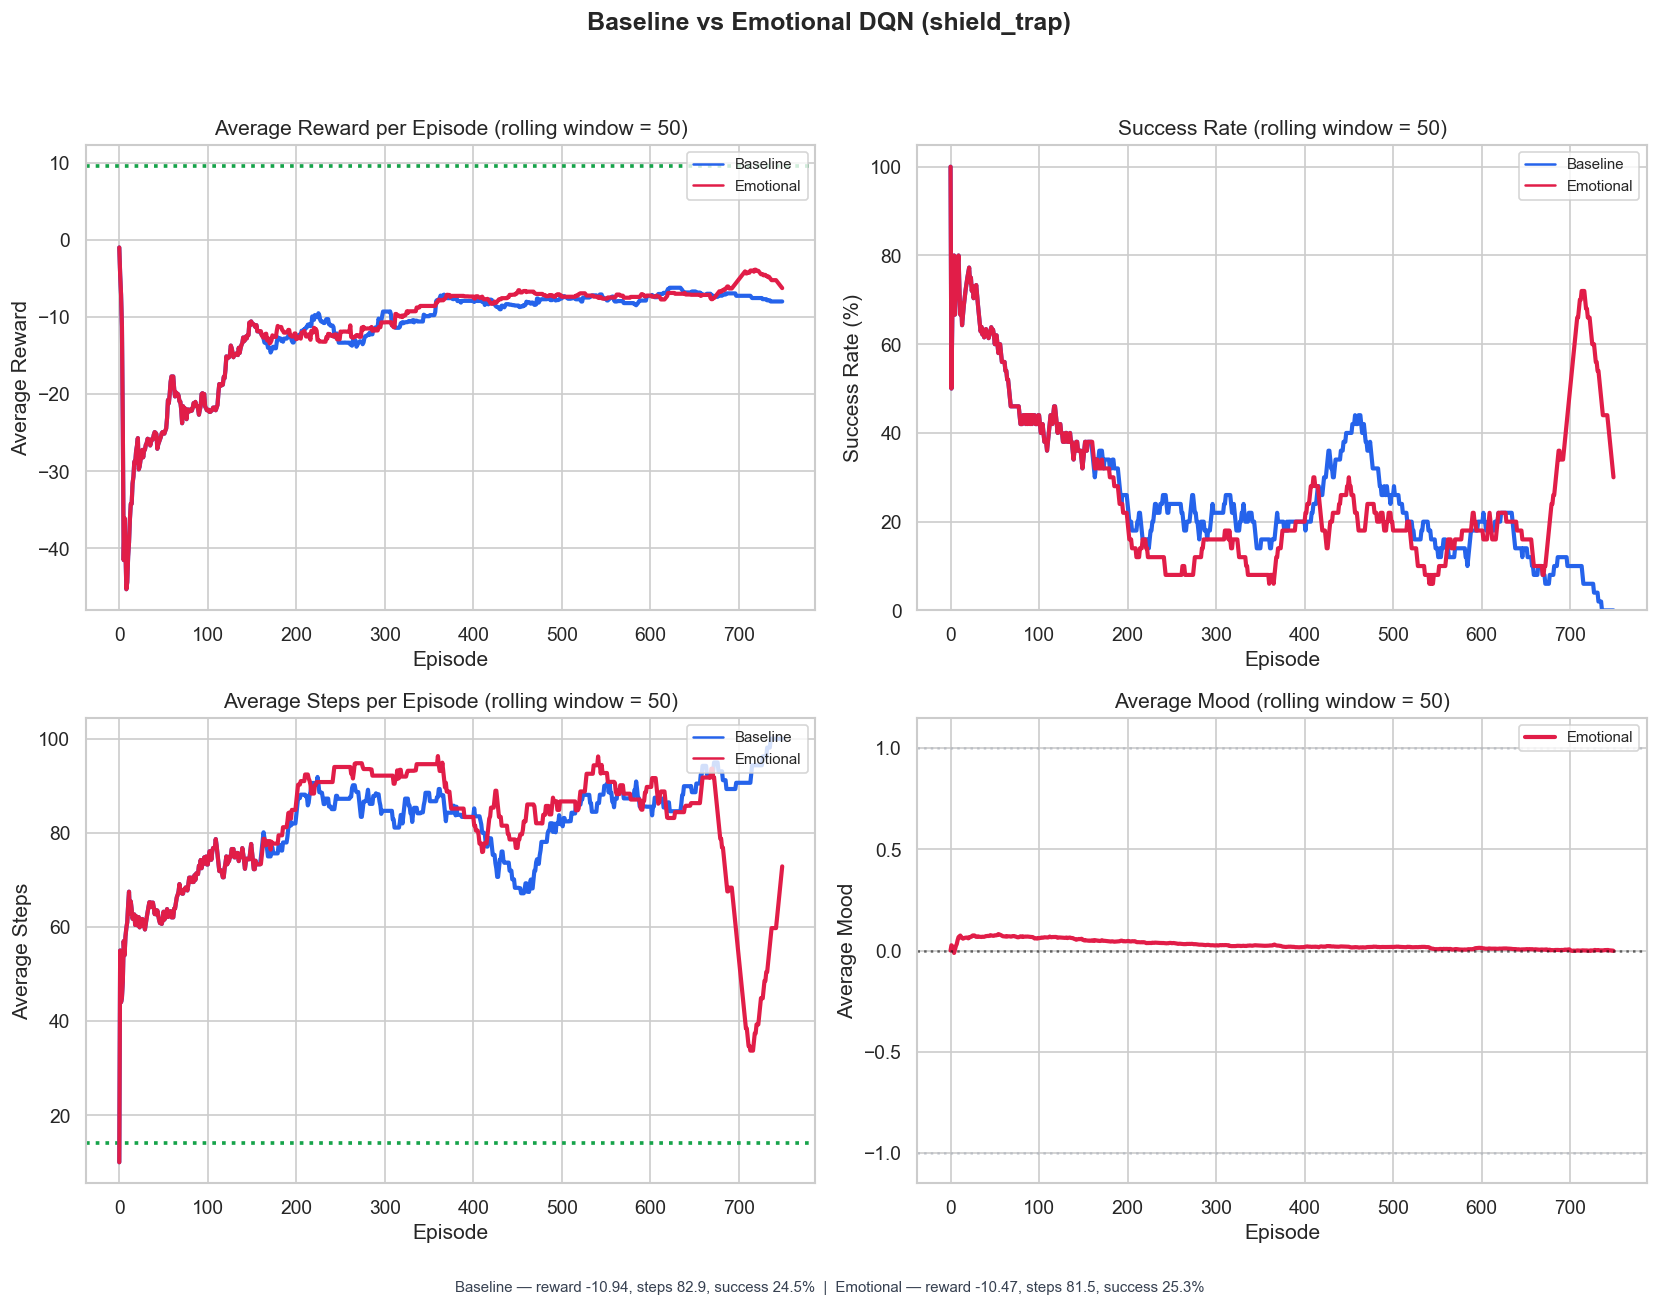

In [6]:
from utils.visualization import plot_agent_comparison

non_empty = {k: v for k, v in data.items() if not v.empty}
fig = plot_agent_comparison(
    non_empty,
    maze_name=MAZE_NAME,
    window=ROLLING_WINDOW,
    show=True,
)

## 3. Path-type breakdown (shield_route vs trap_rush vs timeout)

In [ ]:
has_path_type = any(
    "path_type" in df.columns and df["path_type"].notna().any()
    for df in data.values() if not df.empty
)

if has_path_type:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (agent_type, df) in zip(axes, data.items()):
        if df.empty or "path_type" not in df.columns:
            ax.set_visible(False)
            continue

        # Bin episodes into quarters
        n_eps = df["episode"].max() + 1
        df = df.copy()
        df["quarter"] = pd.cut(
            df["episode"],
            bins=4,
            labels=["Q1", "Q2", "Q3", "Q4"],
        )

        path_counts = (
            df.groupby(["quarter", "path_type"], observed=False)
            .size()
            .unstack(fill_value=0)
        )

        colors_map = {
            "shield_route": "#16a34a",
            "trap_rush": "#dc2626",
            "key_route": "#2563eb",
            "direct": "#f59e0b",
            "timeout": "#6b7280",
            "other": "#a855f7",
        }
        bar_colors = [colors_map.get(c, "#94a3b8") for c in path_counts.columns]

        path_counts.plot.bar(stacked=True, ax=ax, color=bar_colors, width=0.7)
        ax.set_title(f"{agent_type.capitalize()} — path types by quarter")
        ax.set_ylabel("episodes")
        ax.set_xlabel("training quarter")
        ax.legend(fontsize=8, loc="upper left")
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

    # Print totals
    for agent_type, df in data.items():
        if df.empty or "path_type" not in df.columns:
            continue
        counts = Counter(df["path_type"].dropna())
        print(f"\n{agent_type}: {dict(counts)}")
else:
    print("No path_type column found — run training with updated code to get this.")

## 4. Detailed emotional metrics

In [ ]:
from utils.visualization import plot_emotional_metrics

if not data.get("emotional", pd.DataFrame()).empty:
    fig = plot_emotional_metrics(data, smooth_window=ROLLING_WINDOW)
    if fig is not None:
        fig.set_dpi(120)
        plt.show()
else:
    print("No emotional agent data.")

## 5. Summary statistics

In [ ]:
from utils.visualization import print_comparison_summary

print_comparison_summary(data)

# Per-agent final-100 stats
print("\n" + "=" * 60)
print("FINAL 100 EPISODES")
print("=" * 60)

for agent_type, df in data.items():
    if df.empty:
        continue
    tail = df.tail(100)
    print(f"\n{agent_type.upper()}:")
    print(f"  Success rate: {tail['success'].mean():.1%}")
    print(f"  Avg reward:   {tail['total_reward'].mean():.2f}")
    print(f"  Avg steps:    {tail['steps'].mean():.1f}")
    if "path_type" in tail.columns:
        print(f"  Path types:   {dict(Counter(tail['path_type'].dropna()))}")
    if "mean_overall_mood" in tail.columns:
        print(f"  Avg mood:     {tail['mean_overall_mood'].mean():.4f}")

## 6. Q-value policy maps from checkpoints

Loads checkpoints saved during training and renders greedy-policy arrows on the maze grid.

In [ ]:
from environments import VisualMazeEnv
from analyze_policy_evolution import load_agent_checkpoint
from utils.policy_map import plot_policy_map, plot_policy_map_panels

# Find checkpoint manifest
manifest_path = exp_dir / "checkpoint_manifest.json"
if manifest_path.exists():
    with open(manifest_path) as f:
        manifest = json.load(f)
    print(f"Found {len(manifest['runs'])} runs in checkpoint manifest")
else:
    manifest = None
    print("No checkpoint_manifest.json — looking for checkpoints directly")

In [ ]:
def find_checkpoints(run_entry=None):
    """Find checkpoint .pt files from a manifest entry or by scanning."""
    if run_entry is not None:
        ckpt_dir = Path(run_entry["checkpoint_dir"])
    else:
        # Fallback: find any checkpoints/ dir under the experiment
        ckpt_dirs = sorted(exp_dir.rglob("checkpoints"))
        if not ckpt_dirs:
            return []
        ckpt_dir = ckpt_dirs[0]
    return sorted(ckpt_dir.glob("agent_episode_*.pt"),
                  key=lambda p: int(p.stem.split("_episode_")[-1]))


def plot_checkpoint_policy(ckpt_path, agent_type, episode_label):
    """Load one checkpoint and plot its policy map."""
    env = VisualMazeEnv(maze_name=MAZE_NAME, image_size=IMAGE_SIZE)
    agent = load_agent_checkpoint(
        str(ckpt_path), env,
        agent_type=agent_type,
        image_size=IMAGE_SIZE,
    )
    agent.epsilon = 0.0
    fig = plot_policy_map_panels(
        agent, env,
    )
    fig.suptitle(f"{agent_type} — episode {episode_label}", fontsize=13, fontweight="bold")
    fig.set_dpi(120)
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot policy maps for key checkpoints
EPISODES_TO_PLOT = [100, 250, 500, 750]  # adjust as needed

runs_to_plot = []
if manifest is not None:
    runs_to_plot = manifest["runs"]
else:
    # Build a fake entry for each agent type found
    for agent_type in ["baseline", "emotional"]:
        agent_dir = exp_dir / agent_type
        if agent_dir.exists():
            for sub in sorted(agent_dir.iterdir()):
                ckpt_dir = sub / "checkpoints"
                if ckpt_dir.exists():
                    runs_to_plot.append({"agent_type": agent_type, "checkpoint_dir": str(ckpt_dir)})

for run_entry in runs_to_plot:
    agent_type = run_entry["agent_type"]
    checkpoints = find_checkpoints(run_entry)
    if not checkpoints:
        print(f"No checkpoints for {agent_type}")
        continue

    ep_map = {int(p.stem.split("_episode_")[-1]): p for p in checkpoints}
    available = sorted(ep_map.keys())
    print(f"\n{agent_type}: {len(available)} checkpoints — {available}")

    for ep in EPISODES_TO_PLOT:
        if ep in ep_map:
            plot_checkpoint_policy(ep_map[ep], agent_type, ep)
        else:
            # Use closest available
            closest = min(available, key=lambda x: abs(x - ep))
            if abs(closest - ep) < 50:
                print(f"  Episode {ep} not found, using closest: {closest}")
                plot_checkpoint_policy(ep_map[closest], agent_type, closest)

## 7. Policy evolution (Q-values at start position over training)

In [ ]:
from analyze_policy_evolution import analyze_checkpoints, plot_policy_evolution

for run_entry in runs_to_plot:
    agent_type = run_entry["agent_type"]
    ckpt_dir = run_entry["checkpoint_dir"]

    checkpoints = find_checkpoints(run_entry)
    if len(checkpoints) < 3:
        print(f"Skipping {agent_type} — not enough checkpoints")
        continue

    ep_numbers = sorted(int(p.stem.split("_episode_")[-1]) for p in checkpoints)
    # Sample ~8 evenly spaced checkpoints
    indices = np.linspace(0, len(ep_numbers) - 1, min(8, len(ep_numbers)), dtype=int)
    episodes_to_analyze = [ep_numbers[i] for i in indices]

    print(f"\n{agent_type} — analyzing episodes: {episodes_to_analyze}")
    results = analyze_checkpoints(
        checkpoint_dir=ckpt_dir,
        maze_name=MAZE_NAME,
        episodes_to_analyze=episodes_to_analyze,
        agent_type=agent_type,
        image_size=IMAGE_SIZE,
    )

    if results is not None and not results.empty:
        fig = plot_policy_evolution(results)
        fig.suptitle(f"Policy Evolution — {agent_type}", fontsize=14, fontweight="bold")
        fig.set_dpi(120)
        plt.tight_layout()
        plt.show()

## 8. Reward-per-step histogram (successful vs failed episodes)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (agent_type, df) in zip(axes, data.items()):
    if df.empty:
        ax.set_visible(False)
        continue

    success_df = df[df["success"] == True]
    fail_df = df[df["success"] == False]

    bins = np.linspace(df["total_reward"].min(), df["total_reward"].max(), 40)
    ax.hist(fail_df["total_reward"], bins=bins, alpha=0.5, color="#ef4444", label="Failed")
    ax.hist(success_df["total_reward"], bins=bins, alpha=0.7, color="#22c55e", label="Success")
    ax.set_title(f"{agent_type.capitalize()} — reward distribution")
    ax.set_xlabel("Total reward")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()